# Signal Recycling, Resonant Sideband Extraction, and Dual Recycling in Michelson Interferometer

## Signal Recycling
By placing a partially-reflective mirror, the *Signal Recycling Mirror (SRM)*, at the dark port, a new optical cavity is formed between the SRM and the input test masses of the arm cavities. This is the *Signal Recycling Cavity (SRC)*. When the SRC is tuned to resonance for the signal sidebands (SRM tuning $\phi = 0°$), the sidebands are coherently reflected back into the interferometer on each round trip, building up in amplitude inside the SRC in the same way carrier power builds up inside a Fabry-Perot cavity. This configuration is known as **Signal Recycling (SR)** and results in a narrowband enhancement of sensitivity. The detector becomes significantly more sensitive at and around a specific GW frequency, at the cost of reduced response at other frequencies. The higher the reflectivity $R$ of the SRM, the greater the peak gain and the narrower the resulting bandwidth, since higher reflectivity implies more round trips before the sideband leaks out, and only a narrow range of frequencies remain in resonance over many bounces.

## Resonant Sideband Extraction
When the SRM is detuned by a quarter wavelength ($\phi = 90°$), the SRC is placed in anti-resonance for the signal sidebands. This occurs because the differential nature of the GW signal means the sidebands already accumulate a 180° phase shift from the arm cavities: the antisymmetric combination of the X and Y arm contributions. The additional 90° phase per bounce from the detuned SRM brings the total round-trip phase to 360° + 90°, which is off resonance. Rather than trapping the sidebands, the SRC in this configuration actively extracts them, the sidebands exit the arms more rapidly than they would in the absence of the SRM. This regime is known as **Resonant Sideband Extraction (RSE)**. Its effect is to broaden the detector bandwidth: the faster extraction means sidebands at a wide range of GW frequencies exit efficiently, producing a flatter frequency response across a broader band. The trade-off is a reduction in peak sensitivity compared to the SR configuration. Higher SRM reflectivity in RSE mode produces a flatter and broader response, approaching a near-uniform sensitivity across the entire detection band.

## Dual Recycling
The combination of a Power Recycling Mirror (PRM) at the bright port and an SRM at the dark port constitutes a *dual recycling interferometer*. The PRM forms the Power Recycling Cavity (PRC) with the input test masses, enhancing the circulating carrier power and thereby increasing the shot-noise-limited sensitivity uniformly across all frequencies. The SRM simultaneously shapes the signal response through either SR or RSE, as described above. Together, the two recycling mirrors provide independent control over the carrier power (via the PRM) and the signal bandwidth and peak sensitivity (via the SRM), making dual recycling the standard optical configuration adopted in second-generation GW detectors such as Advanced LIGO and Advanced Virgo.

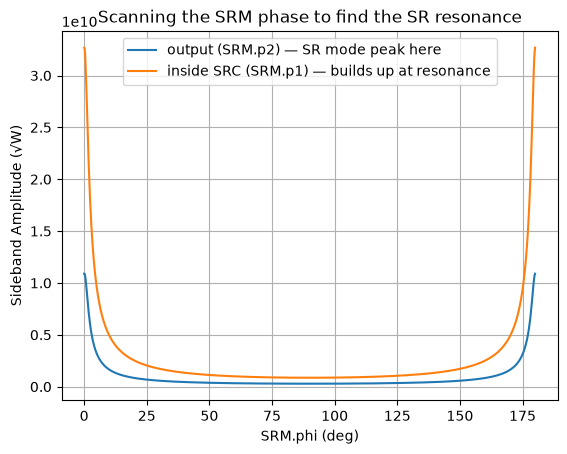

In [6]:
import finesse
from finesse.analysis.actions import Xaxis
import numpy as np
import matplotlib.pyplot as plt

model = finesse.Model()
model.parse("""
l L0 P=1
s s0 L0.p1 BS.p1 L=1

bs BS R=0.5 T=0.5 phi=0 alpha=45

s syarm BS.p3 ETMy.p1 L=600
m ETMy T=100e-6 L=0 phi=0

s sxarm BS.p2 ETMx.p1 L=600
m ETMx T=100e-6 L=0 phi=90

s s_src BS.p4 SRM.p1 L=10
m SRM R=0.9 T=0.1 phi=0       # we'll scan this

sgen sigY syarm.h phase=180
sgen sigX sxarm.h phase=0
fsig(100)                      # fix signal at 100 Hz for the scan

ad upper node=SRM.p2.o f=fsig.f   # sideband power leaking out
ad circ_src node=SRM.p1.o f=fsig.f  # sideband power inside SRC
""")

out = model.run(Xaxis("SRM.phi", "lin", 0, 180, 1000))

plt.plot(out.x[0], np.abs(out['upper']),    label='output (SRM.p2) — SR mode peak here')
plt.plot(out.x[0], np.abs(out['circ_src']), label='inside SRC (SRM.p1) — builds up at resonance')
plt.xlabel('SRM.phi (deg)')
plt.ylabel('Sideband Amplitude (√W)')
plt.title('Scanning the SRM phase to find the SR resonance')
plt.legend()
plt.grid()
plt.show()

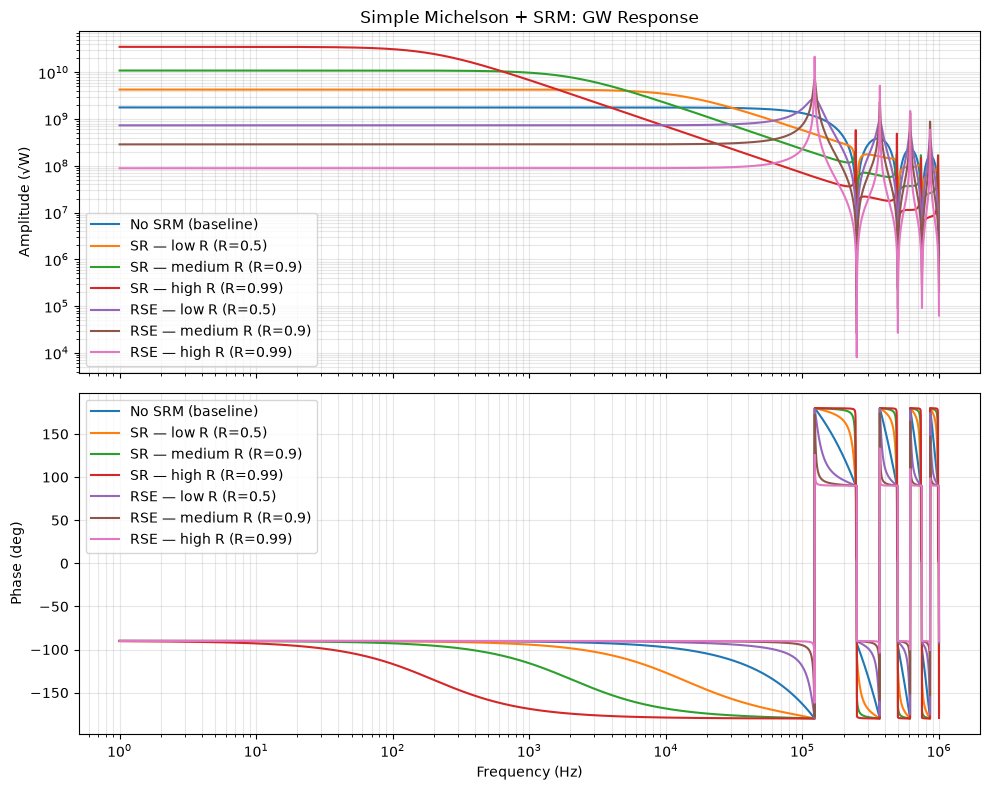

In [7]:
import finesse
from finesse.analysis.actions import Xaxis
import numpy as np
import matplotlib.pyplot as plt

model = finesse.Model()

def build_model(srm_R, srm_phi):
    model = finesse.Model()
    model.parse(f"""
    l L0 P=1
    s s0 L0.p1 BS.p1 L=1

    bs BS R=0.5 T=0.5 phi=0 alpha=45

    s syarm BS.p3 ETMy.p1 L=600
    m ETMy T=100e-6 L=0 phi=0

    s sxarm BS.p2 ETMx.p1 L=600
    m ETMx T=100e-6 L=0 phi=90

    # SRM at the dark port
    s s_src BS.p4 SRM.p1 L=10
    m SRM R={srm_R} T={1-srm_R} phi={srm_phi}

    pd dark SRM.p2.o

    sgen sigY syarm.h phase=180
    sgen sigX sxarm.h phase=0
    fsig(1)
    ad upper node=SRM.p2.o f=fsig.f
    """)
    return model

configs = {
    'No SRM (baseline)':        (0.0,   0),
    'SR — low R (R=0.5)':       (0.5,   0),
    'SR — medium R (R=0.9)':    (0.9,   0),
    'SR — high R (R=0.99)':     (0.99,  0),
    'RSE — low R (R=0.5)':      (0.5,  90),
    'RSE — medium R (R=0.9)':   (0.9,  90),
    'RSE — high R (R=0.99)':    (0.99, 90),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for label, (R, phi) in configs.items():
    m = build_model(R, phi)
    out = m.run(Xaxis("fsig.f", "log", 1, 1e6, 5000))
    ax1.plot(out.x[0], np.abs(out['upper']), label=label)
    ax2.plot(out.x[0], np.angle(out['upper'], deg=True), label=label)

ax1.set_yscale('log')
ax1.set_ylabel('Amplitude (√W)')
ax1.set_title('Simple Michelson + SRM: GW Response')
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

ax2.set_ylabel('Phase (deg)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()